In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

import glob

In [2]:
grite_txts = glob.glob('../../grite_outputs/*.txt')

In [3]:
path_test = grite_txts[0]

In [4]:
df_all = []
for path in grite_txts:
    df = pd.read_csv(path, sep='\t')
    df_all.append(df)


In [5]:
df_all = pd.concat(df_all, ignore_index=True)

In [6]:
df_all.shape

(4126, 6)

In [7]:
df_all["data"].unique()

array(['hcv_pca', 'hcv_clean', 'chickenpox_pca', 'cargo2000_pca'],
      dtype=object)

In [8]:
df_all["sup_min"].unique()

array([0.34, 0.1 , 0.2 , 0.18, 0.5 , 0.04, 0.38, 0.16, 0.24, 0.7 , 0.4 ,
       0.8 , 0.08, 0.9 , 0.14, 0.6 , 0.28, 0.3 , 1.  ])

In [9]:
hcv_pca = df_all[df_all["data"]=='hcv_pca']

In [10]:
for sup_min in hcv_pca["sup_min"].unique():
    print(f"sup_min: {sup_min}")
    
    hcv_pca_subset = hcv_pca[hcv_pca['sup_min'] == sup_min]
    nb_supports = hcv_pca_subset['total'].unique()
    
    df_correct = hcv_pca_subset[-nb_supports[0]:]
    print(df_correct)
    print(f"Number of supports: {nb_supports[0]}")
    print("\n")

sup_min: 0.34
                   motif  support  sup_min     data  execution_time  total
20    ['Age+', 'Age.1+']      1.0     0.34  hcv_pca      731.414079      6
21    ['Age-', 'Age.1-']      1.0     0.34  hcv_pca      731.414079      6
22  ['CREA+', 'CREA.1+']      1.0     0.34  hcv_pca      731.414079      6
23  ['CREA-', 'CREA.1-']      1.0     0.34  hcv_pca      731.414079      6
24    ['GGT+', 'GGT.1+']      1.0     0.34  hcv_pca      731.414079      6
25    ['GGT-', 'GGT.1-']      1.0     0.34  hcv_pca      731.414079      6
Number of supports: 6


sup_min: 0.2
                    motif  support  sup_min     data  execution_time  total
216    ['Age+', 'Age.1+']      1.0      0.2  hcv_pca      714.423924      6
217    ['Age-', 'Age.1-']      1.0      0.2  hcv_pca      714.423924      6
218  ['CREA+', 'CREA.1+']      1.0      0.2  hcv_pca      714.423924      6
219  ['CREA-', 'CREA.1-']      1.0      0.2  hcv_pca      714.423924      6
220    ['GGT+', 'GGT.1+']      1.0      0.2 

In [11]:
def resume_supports(hcv_pca):
    recap_data = []
    motif_support_dict = {}

    for sup_min in hcv_pca["sup_min"].unique():
        hcv_pca_subset = hcv_pca[hcv_pca['sup_min'] == sup_min]
        nb_supports = hcv_pca_subset['total'].unique()
        
        subset = hcv_pca_subset[-nb_supports[0]:]
        time = subset['execution_time'].unique()[0]
        
       
        
        recap_data.append( {
            'execution_time': time,
            'sup_min': sup_min,
            'number of patterns': subset['total'].unique()[0]
        })
        
        for _, row in subset.iterrows():  
            motif = row['motif']  
            support = row['support'] 
            motif_support_dict[motif] = support

    recap_df = pd.DataFrame(recap_data)
    return recap_df, motif_support_dict


In [12]:
hcv = df_all[df_all["data"]=='hcv_clean']
hcv_pca = df_all[df_all["data"]=='hcv_pca']

In [13]:
df_pca, dict_ = resume_supports(hcv_pca)
df_hcv, dict_2 = resume_supports(hcv)


In [14]:
df_hcv["Dataset"] = "HCV" 
df_pca['Dataset'] = "HCV PCA"
 
df_clean = pd.concat([df_hcv, df_pca], ignore_index=True)

In [15]:
df_hcv

,execution_time,sup_min,number of patterns,Dataset
0,5093.193844,0.10,148,HCV
1,822.026133,0.16,0,HCV
2,14600.452404,0.04,556,HCV
3,805.789907,0.70,0,HCV
4,793.106854,0.40,0,HCV
5,799.179692,0.80,0,HCV
6,788.094860,0.24,0,HCV
7,822.429693,0.90,0,HCV
8,991.050312,0.14,16,HCV
9,822.631953,0.28,0,HCV


In [16]:
import seaborn as sns

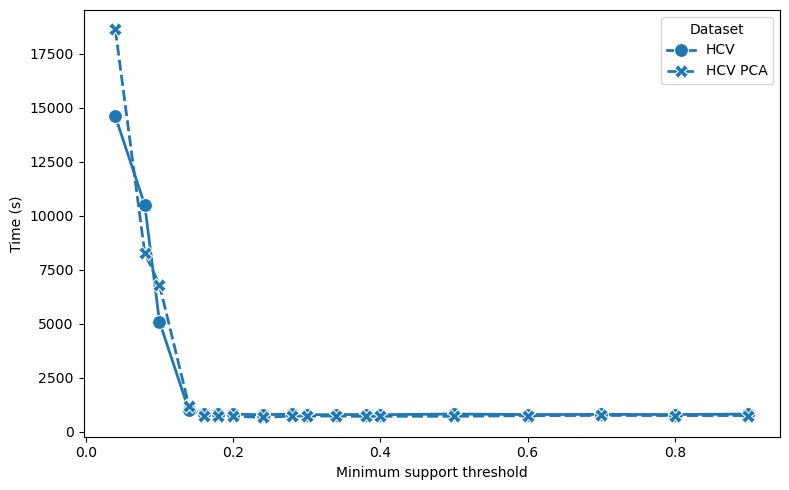

In [17]:
plt.figure(figsize=(8, 5))
sns.lineplot(
        data=df_clean,
        x="sup_min",
        y="execution_time",
        markers=True, 
        style="Dataset", 
        linewidth=2,  
        markersize=10,  
    )

plt.ylabel("Time (s)")
plt.xlabel('Minimum support threshold')

plt.tight_layout()
plt.show()


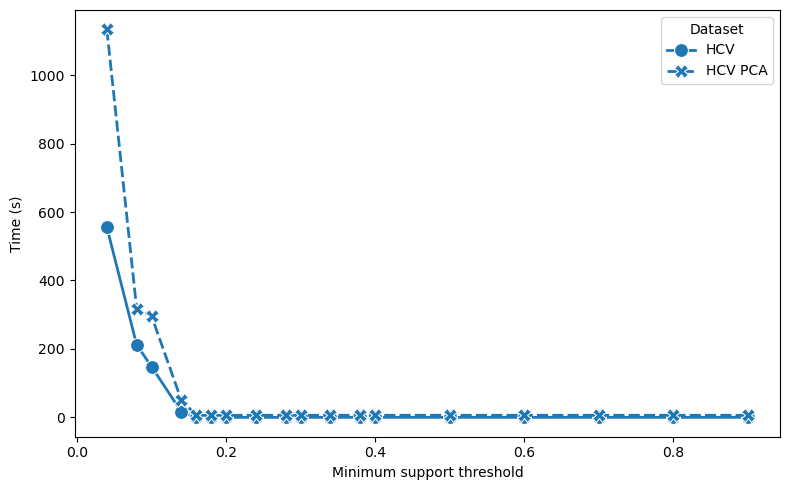

In [18]:
plt.figure(figsize=(8, 5))
sns.lineplot(
        data=df_clean,
        x="sup_min",
        y="number of patterns",
        markers=True, 
        style="Dataset", 
        linewidth=2,  
        markersize=10,  
    )

plt.ylabel("Time (s)")
plt.xlabel('Minimum support threshold')

plt.tight_layout()
plt.show()


# 1 -  chickenpox Data set

In [19]:
df_all["data"].unique()

array(['hcv_pca', 'hcv_clean', 'chickenpox_pca', 'cargo2000_pca'],
      dtype=object)

In [20]:
chickenpox_pca = df_all[df_all["data"]=='chickenpox_pca']

In [21]:
chickenpox_pca

,motif,support,sup_min,data,execution_time,total
248,['HEVES+'],1.000000,0.5,chickenpox_pca,129.614624,2
249,['HEVES-'],1.000000,0.5,chickenpox_pca,129.614624,2
250,['SZABOLCS+'],1.000000,0.5,chickenpox_pca,129.614624,2
251,['SZABOLCS-'],1.000000,0.5,chickenpox_pca,129.614624,2
252,['CSONGRAD+'],1.000000,0.5,chickenpox_pca,129.614624,2
...,...,...,...,...,...,...
4121,"['CSONGRAD-', 'CSONGRAD.1+', 'HEVES-', 'SZABOL...",0.026820,1.0,chickenpox_pca,549.980153,72
4122,"['CSONGRAD-', 'CSONGRAD.1+', 'HEVES+', 'SZABOL...",0.026820,1.0,chickenpox_pca,549.980153,72
4123,"['CSONGRAD+', 'CSONGRAD.1-', 'HEVES-', 'SZABOL...",0.026820,1.0,chickenpox_pca,549.980153,72
4124,"['CSONGRAD-', 'CSONGRAD.1-', 'HEVES+', 'SZABOL...",0.038314,1.0,chickenpox_pca,549.980153,72


In [22]:
chi_pca_df, chick_dic = resume_supports(chickenpox_pca)


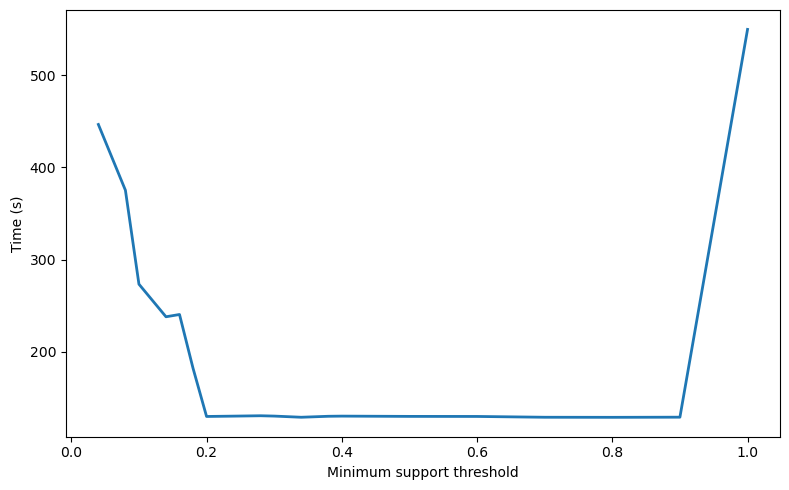

In [23]:
plt.figure(figsize=(8, 5))
sns.lineplot(
        data=chi_pca_df,
        x="sup_min",
        y="execution_time",
        markers=True, 
        linewidth=2,  
        markersize=10,  
    )

plt.ylabel("Time (s)")
plt.xlabel('Minimum support threshold')

plt.tight_layout()
plt.show()
